In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from modules import SAB, ISAB, PMA
from models import DeepSet, SetTransformer, CondSM
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import math

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [4]:
batch = np.load('/gpfs/bwfor/work/ws/hd_gy283-my_data/data_uni_samples_1e6/batch_0.npz')

acc_xy = batch['acc_xy'][12]
n_a = acc_xy.shape[0]
radius = 150.0
R = np.sqrt(np.pi * radius**2 / n_a)
#print(batch.files)
#print(batch['adj_mat'].shape)
#plt.imshow(batch['adj_mat'][0])

g_1 = batch['adj_mat'][0]
print(g_1.shape)

(208, 208)


In [3]:
from train_sm import train_val_test_loaders, MakeDataset
from pathlib import Path

import json

data_dir = Path('/gpfs/bwfor/work/ws/hd_gy283-my_data/data_uni_samples_1e6/')

output_idx = 0
batch_size = 1024
num_batches = 400
train_size = 0.8
val_size = 0.1
test_size = 0.1

voltages = []
configurations = []
currents = []

for i in range(num_batches):

    fp = data_dir / f'batch_{i}.npz'
    try:
        batch = np.load(fp)
    except FileNotFoundError:
        continue        

    voltages.append(batch['inputs'])
    configurations.append(batch['acc_xy'])    

    if batch['currents'].ndim != 1:
        currents.append(batch['currents'][:, output_idx])
    else:
        currents.append(batch['currents'])

V = np.concatenate(voltages)[:, [i for i in range(voltages[0].shape[1]) if i != output_idx]]
X = np.concatenate(configurations)
y = np.concatenate(currents)

len_dataset = V.shape[0]

X = X * R / radius

X_train, X_val_test, V_train, V_val_test, y_train, y_val_test = train_test_split(X, V, y, train_size=train_size, random_state=np.random.randint(0, 2**31 - 1), shuffle=True)

X_val = X_val_test[:int(val_size*len_dataset), ...]
X_test = X_val_test[int(val_size*len_dataset):, ...]

V_val = V_val_test[:int(val_size*len_dataset), ...]
V_test = V_val_test[int(val_size*len_dataset):, ...]

y_val = y_val_test[:int(val_size*len_dataset), ...]
y_test = y_val_test[int(val_size*len_dataset):, ...]

v_mean = V_train.mean(0)
v_std = V_train.std(0)

y_mean = y_train.mean()
y_std = y_train.std()

noise_level = 0.01

if noise_level is not None and noise_level > 0.0:
    X_train = X_train + np.random.normal(loc=0.0, scale=noise_level, size=X_train.shape)
    V_train = V_train + np.random.normal(loc=0.0, scale=noise_level, size=V_train.shape)

class TwoInputDataset(Dataset):
    def __init__(self, X, V, y):
        
        self.X = torch.as_tensor(X, dtype=torch.float32)
        self.V = torch.as_tensor(V, dtype=torch.float32)
        self.y = torch.as_tensor(y, dtype=torch.float32)

        if self.y.dim() == 1:
            self.y = self.y.unsqueeze(1)

        assert len(self.X) == len(self.V) == len(self.y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.V[idx], self.y[idx]

train_set = TwoInputDataset(X_train, V_train, y_train)
val_set = TwoInputDataset(X_val, V_val, y_val)

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print(f"train_set: {len(train_loader.dataset)}")
print(f"val_set: {len(val_loader.dataset)}")
print(f"test_set: {len(X_test)}")

train_set: 160000
val_set: 20000
test_set: 20000


In [4]:
ds_h_dim = 90
ds_out_dim = 4

num_electrodes = 7
sm_in_dim = num_electrodes + ds_out_dim
sm_h_dim = 90
sm_out_dim = 2
sm_layer_dims = [sm_in_dim, sm_h_dim, sm_h_dim, sm_h_dim, sm_out_dim]

num_outputs = 1
d_out = 5

def mog_nll(X, Y):

    B, N, D = X.shape
    _, K, D_out = Y.shape

    w_logit = Y[..., 0]
    mu = Y[..., 1:3]
    log_std = Y[..., 3:5]

    log_pi = torch.log_softmax(w_logit, dim=-1)
    sigma = F.softplus(log_std) + 1e-6

    x         = X.unsqueeze(2)         # [B, N, 1, 2]
    mu_exp    = mu.unsqueeze(1)        # [B, 1, K, 2]
    sigma_exp = sigma.unsqueeze(1)     # [B, 1, K, 2]
    log_s_exp = torch.log(sigma_exp)   # or use log_s.unsqueeze(1)

    # 4. Component-wise log-probabilities log N(x | mu_k, sigma_k^2 I)
    z = (x - mu_exp) / sigma_exp       # [B, N, K, 2]
    const = -0.5 * D * np.log(2 * np.pi)
    log_prob_per_dim = const - 0.5 * (2 * log_s_exp + z**2)   # [B, N, K, 2]
    log_prob_comp = log_prob_per_dim.sum(dim=-1)              # [B, N, K]

    # 5. Mix with weights: log p(x_i) = logsumexp_k ( log π_k + log N_k )
    log_pi_exp = log_pi.unsqueeze(1)           # [B, 1, K]
    log_weighted = log_pi_exp + log_prob_comp  # [B, N, K]
    log_prob_x = torch.logsumexp(log_weighted, dim=-1)  # [B, N]

    # 6. Sum over points, average over batch → NLL
    log_likelihood_per_set = log_prob_x.sum(dim=-1)   # [B]
    nll = -log_likelihood_per_set.mean()              # scalar

    return nll

def neg_ll(target, y):

    target = target.squeeze(-1)
    mu = y[..., 0]
    log_std = y[..., 1]
    
    N, d_out = y.shape

    sigma = F.softplus(log_std) + 1e-6
    var = sigma ** 2

    nll = 0.5 * ( 
        (target - mu) ** 2 / var 
        + 2 * torch.log(sigma) 
        + math.log(2 * math.pi) 
    )

    return nll.mean()

In [24]:
def sort_by_radius(x):
    r2 = (x ** 2).sum(dim=-1)
    r2_sorted, idx = torch.sort(r2, dim=1)
    pts_sorted = torch.gather(
        x, 
        dim=1,
        index=idx.unsqueeze(-1).expand(-1, -1, 2)
    )

    return pts_sorted

In [39]:
#deep_set = DeepSet(in_dim=2, h_dim=ds_h_dim, num_outputs=1, out_dim=ds_out_dim, aggr_type='mean')

h_dim = 64
deep_set = nn.Sequential(
    nn.Linear(400, h_dim),
    nn.Dropout(p=0.2),
    nn.ReLU(),
    nn.Linear(h_dim, h_dim),
    nn.Dropout(p=0.2),
    nn.ReLU(),
    nn.Linear(h_dim, h_dim),
    nn.Dropout(p=0.2),
    nn.ReLU(),
    nn.Linear(h_dim, ds_out_dim),
)

#deep_set = SetTransformer(in_dim=2, num_outputs=1, out_dim=ds_out_dim)
cond_sm = CondSM(layer_dims=sm_layer_dims, dropout_p=0.1, batch_norm=True)

deep_set = deep_set.to(device)
cond_sm = cond_sm.to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(
    list(deep_set.parameters()) + list(cond_sm.parameters()), 
    lr=1e-3
)

train_losses = []
val_losses = []

num_epochs = 100

with tqdm(total=num_epochs, desc="Epochs") as pbar:
    for epoch in range(1, num_epochs + 1):
    
        deep_set.train()
        cond_sm.train()
        running_loss = 0.0
        for x, v, y in train_loader:
            bs = x.size(0)
            x = sort_by_radius(x)
            x = x.view(bs, 200*2)
            x = x.to(device, non_blocking=True).float()
            v = v.to(device, non_blocking=True).float()
            y = y.to(device, non_blocking=True).float()
            
            #y = (y - y_mean) / y_std
            
            optimizer.zero_grad()
            
            z = deep_set(x).squeeze(dim=1)
            
            sm_input = torch.cat([v, z], dim=1).to(device)
            preds = cond_sm(sm_input)
    
            #loss = criterion(preds, y)
            loss = neg_ll(y, preds)
            loss.backward()
            optimizer.step()
    
            running_loss += loss.item() * x.size(0)
    
        epoch_train_loss = running_loss / len(train_loader.dataset)
    
        deep_set.eval()
        cond_sm.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x, v, y in val_loader:
                bs = x.size(0)
                x = sort_by_radius(x)
                x = x.view(bs, 200*2)
                x = x.to(device, non_blocking=True).float()
                v = v.to(device, non_blocking=True).float()
                y = y.to(device, non_blocking=True).float()
                
                #y = (y - y_mean) / y_std
    
                z = deep_set(x).squeeze(dim=1)
                sm_input = torch.cat([v, z], dim=1).to(device)
                preds = cond_sm(sm_input)
    
                #loss  = criterion(preds, y)
                loss = neg_ll(y, preds)
                
                val_loss += loss.item() * x.size(0)
    
        epoch_val_loss = val_loss / len(val_loader.dataset)
    
        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)
    
        pbar.set_postfix({
            "epoch": f"{epoch}/{num_epochs}",
            "train": f"{epoch_train_loss:.4f}",
            "val": f"{epoch_val_loss:.4f}"
        })
        pbar.update(1)

torch.save({
    "deep_set_state_dict": deep_set.state_dict(),
    "cond_sm_state_dict": cond_sm.state_dict(),
    "train_losses": train_losses,
    "val_losses": val_losses
}, f"/gpfs/bwfor/work/ws/hd_gy283-my_data/models/sm_cond_mog_NN_nll.pth")

print(f"Model has been saved!")

Epochs: 100%|██████████| 100/100 [04:41<00:00,  2.82s/it, epoch=100/100, train=-1.1579, val=-0.9900]

Model has been saved!


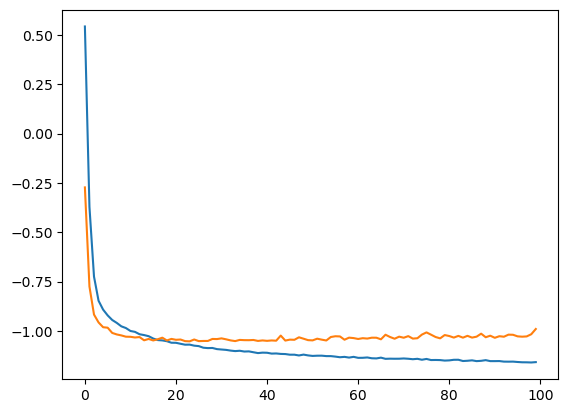

In [42]:
#deep_set = SetTransformer(in_dim=2, num_outputs=1, out_dim=ds_out_dim)
#deep_set = DeepSet(in_dim=2, h_dim=ds_h_dim, num_outputs=1, out_dim=ds_out_dim, aggr_type='mean')
deep_set = nn.Sequential(
    nn.Linear(400, h_dim),
    nn.Dropout(p=0.2),
    nn.ReLU(),
    nn.Linear(h_dim, h_dim),
    nn.Dropout(p=0.2),
    nn.ReLU(),
    nn.Linear(h_dim, h_dim),
    nn.Dropout(p=0.2),
    nn.ReLU(),
    nn.Linear(h_dim, ds_out_dim),
)
cond_sm = CondSM(layer_dims=sm_layer_dims, dropout_p=0.1, batch_norm=True)

model_dict = torch.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/models/sm_cond_mog_NN_nll.pth')

deep_set.load_state_dict(model_dict['deep_set_state_dict'])
cond_sm.load_state_dict(model_dict['cond_sm_state_dict'])

deep_set = deep_set.to(device)
cond_sm = cond_sm.to(device)

plt.plot(model_dict['train_losses'])
plt.plot(model_dict['val_losses'])
#plt.yscale('log')

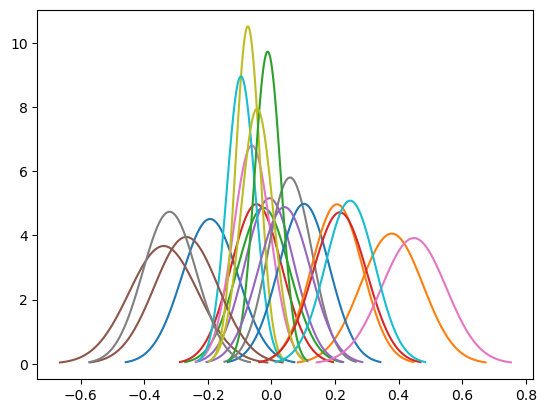

In [43]:
import scipy.stats as stats

test_set = TwoInputDataset(X_test, V_test, y_test)
test_loader = DataLoader(test_set, batch_size=256, shuffle=False)

deep_set.eval()
cond_sm.eval()

pred_params = []
y_true_l = []
latent_l = []
with torch.no_grad():
    for x, v, y in test_loader:
        bs = x.size(0)
        x = sort_by_radius(x)
        x = x.view(bs, 200*2)
        x = x.to(device, non_blocking=True).float()
        v = v.to(device, non_blocking=True).float()
        y = y.to(device, non_blocking=True).float()

        z = deep_set(x).squeeze()
        
        sm_input = torch.cat([v, z], dim=1)
        preds = cond_sm(sm_input).detach().cpu().numpy()
        pred_params.append(preds)
        y_true_l.append(y.cpu().numpy())
        latent_l.append(z.detach().cpu().numpy())

y_pred_l = [params[..., 0] for params in pred_params]
batch = 10
params = pred_params[batch]
for i in range(20):#params.shape[0]):
    mu = params[i, 0]
    std = np.log1p(np.exp(params[i, 1])) + 1e-6

    x = np.linspace(mu - 3*std, mu + 3*std, 100)
    plt.plot(x, stats.norm.pdf(x, mu, std))

In [37]:
"""zs = np.concatenate(latent_l, axis=0)

zx_min = zs[:, 0].min()
zx_max = zs[:, 0].max()

zy_min = zs[:, 1].min()
zy_max = zs[:, 1].max()

z_ranges = [[zx_min, zx_max], [zy_min, zy_max]]

fig, ax = plt.subplots()

_, _, _, im = ax.hist2d(*zs.T, bins=150, range=z_ranges, cmap='jet')

ax.set_box_aspect(1)
ax.set_xlabel(r'$z_1$')
ax.set_ylabel(r'$z_2$')"""

"zs = np.concatenate(latent_l, axis=0)\n\nzx_min = zs[:, 0].min()\nzx_max = zs[:, 0].max()\n\nzy_min = zs[:, 1].min()\nzy_max = zs[:, 1].max()\n\nz_ranges = [[zx_min, zx_max], [zy_min, zy_max]]\n\nfig, ax = plt.subplots()\n\n_, _, _, im = ax.hist2d(*zs.T, bins=150, range=z_ranges, cmap='jet')\n\nax.set_box_aspect(1)\nax.set_xlabel(r'$z_1$')\nax.set_ylabel(r'$z_2$')"

0.093447715
0.21659872952267503
-0.88336825 0.8343373


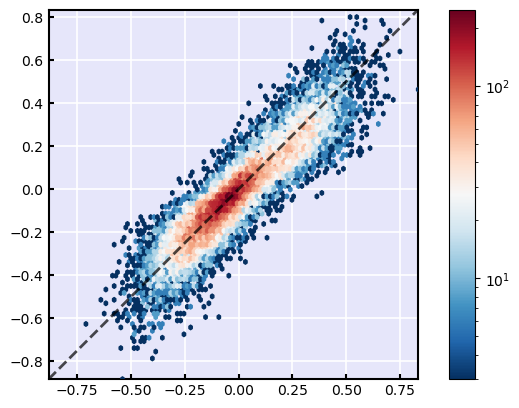

In [44]:
from utils import pred_vs_true
from matplotlib.colors import LogNorm

y_pred = np.concatenate(y_pred_l, axis=0).ravel()
y_true = np.concatenate(y_true_l, axis=0).ravel()

#y_true = (y_true - y_mean) / y_std

target_mean = np.mean(y_true)

rmse = np.sqrt(np.mean((y_pred - y_true)**2))
rmse_to_mean = np.sqrt(np.mean((y_pred - y_mean)**2))

print(rmse)
print(rmse_to_mean)

lo = min(y_pred.min(), y_true.min())
hi = min(y_pred.max(), y_true.max())
print(lo, hi)
plot_range = [[lo, hi], [lo, hi]]

fig, ax = plt.subplots()

ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)

norm = LogNorm()

im = ax.hexbin(y_pred, y_true, bins=250, gridsize=100, norm=norm, cmap="RdBu_r", zorder=5)
#_, _, _, im = ax.hist2d(y_pred, y_true, bins=200, range=plot_range, norm=norm, cmap="RdBu", zorder=5)
ax.plot([lo, hi], [lo, hi], linestyle='--', linewidth=2, color='k', alpha=0.7, zorder=6)

fig = ax.figure
cax = fig.add_axes([ax.get_position().x1 - 0.05, ax.get_position().y0, 0.04, ax.get_position().height])
plt.colorbar(im, cax=cax)

ax.spines[:].set_linewidth(1.5)
ax.spines[:].set_facecolor('w')
ax.tick_params(direction='in', width=1.5)
ax.set_facecolor('lavender')
ax.grid(c='w', lw=1.2)

ax.set_aspect('equal', adjustable='box')

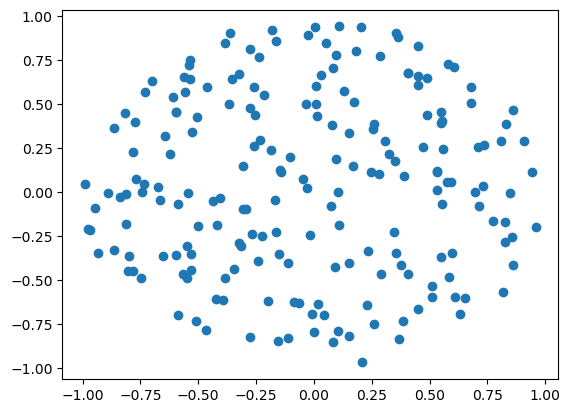

In [46]:
from utils import create_dopant_configuration

acc_angles, don_angles, r_acc, r_don = create_dopant_configuration(radius, n_a=200, n_d=3, name_a='test_acc_uni', name_d='test_don_uni', mode='uniform', eps=None, save_dir='/home/hd/hd_hd/hd_gy283/kmc_project/configs/')

acc = np.loadtxt('/home/hd/hd_hd/hd_gy283/kmc_project/configs/test_acc_uni.txt')
acc = acc / radius

plt.scatter(*acc.T)

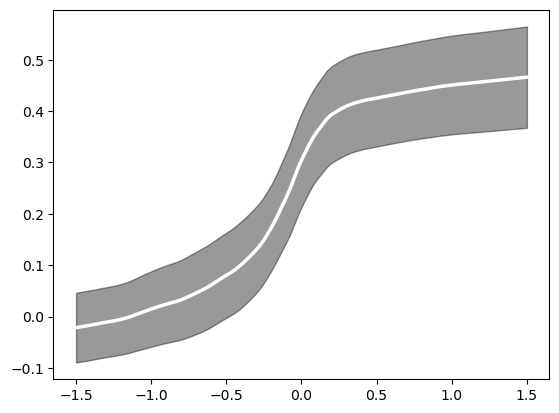

In [55]:
deep_set.eval()
cond_sm.eval()

N = 100
c_list = [0.2, 1.1, -0.5, -1, 0.5, 0.7]
c_volts = torch.tensor(c_list, dtype=torch.float32).expand(N, -1)
volt_range = torch.linspace(-1.5, 1.5, N).unsqueeze(1)

input_tensor = torch.cat([volt_range, c_volts], dim=1)
geom_tensor = torch.from_numpy(acc).float().unsqueeze(0).expand(N, 200, 2)

input_tensor = input_tensor.to(device)
geom_tensor = geom_tensor.to(device)
geom_tensor = geom_tensor.view(-1, 400)

with torch.no_grad():
    z = deep_set(geom_tensor).squeeze(dim=1)  
    sm_input = torch.cat([input_tensor, z], axis=1)
    y = cond_sm(sm_input).detach().cpu().numpy()

mu = y[..., 0]
mu_std = F.softplus(torch.from_numpy(y[..., 1])).numpy()
test_simulation = np.load('/gpfs/bwfor/work/ws/hd_gy283-my_data/sm_test.npz')
current = test_simulation['current'] / 1.602176634e-19
sem = test_simulation['sem'] / 1.602176634e-19
vs = np.linspace(-1.5, 1.5, N)
plt.plot(vs, mu, c='w', lw=2.5)
plt.fill_between(vs, mu-mu_std, mu+mu_std, color='k', alpha=.4)
#plt.fill_between(vs, current-sem, current+sem, color='orange')

plt.show()